# Libraries used 

In [1]:
import pickle
import numpy as np
import matplotlib.pyplot as plt

# Functions Used

In [2]:
#this function simulates one walker for n steps
def walker_G (r_right, r_left, r_up, r_down, t_max):
    t = [0]
    x = [0]
    y = [0]
    r_total = r_right + r_left + r_up + r_down

    p_1 = r_right/r_total
    p_2 = (r_right+r_left)/r_total
    p_3 = (r_right+r_left+r_up)/r_total

    i = 0
    t_min = t[-1]
    while (t_min < t_max):
        p = np.random.random()
        t_min = t[i]+((-1)*np.log(1-p)/r_total)
        t.append(t_min)
        if ( p <= p_1 ):
            x.append(x[i]+1)
            y.append(y[i])
        elif ( p > p_1 and p <= p_2 ):
            x.append(x[i]-1)
            y.append(y[i])
        elif ( p > p_2 and p <= p_3 ):
            x.append(x[i])
            y.append(y[i]+1)
        else:
            x.append(x[i])
            y.append(y[i]-1)
        i+=1
    array = [t,x,y]
    return (array)

#This is a function equalizes arrays so it is easier to take average
def equalize(arr):
    s_x = arr[1]
    s_y = arr[2]
    s_t = arr[0]
    x_fin = np.zeros(1000)
    y_fin = np.zeros(1000)
    t_fin = np.linspace(0,s_t[-1],1000)
    count = 0
    for i in range(1000):
        if (t_fin[i] <= s_t[count]):
            x_fin[i] = s_x[count]
            y_fin[i] = s_y[count]
        else:
            count+=1
            x_fin[i] = s_x[count]
            y_fin[i] = s_y[count]
            
    eqq_arr = [t_fin, x_fin, y_fin]
    return (eqq_arr)

#generates all 10e5 realizations of the walker
def data_generator(r_right, r_left, r_up, r_down, t_max):
    all_data = []
    for i in range(100000):
        cr_data = walker_G(r_right, r_left, r_up, r_down, t_max)
        eq_data = equalize(cr_data)
        all_data.append(eq_data)
    return (all_data)


def average(data):
    arr = np.average(data,0)
    arr_1 = [arr[1], arr[2]]
    return (arr_1)
            
def squared_average(data):
    arr = np.average(np.power(data,2),0)
    arr_1 = [arr[1], arr[2]]
    return (arr_1)


#simulates Random walker and gives the final positions and time for walker
def walker_final_pos (r_right, r_left, r_up, r_down, t_max):
    x = 0
    y = 0
    r_total = r_right + r_left + r_up + r_down

    p_1 = r_right/r_total
    p_2 = (r_right+r_left)/r_total
    p_3 = (r_right+r_left+r_up)/r_total

    i = 0
    t_min = 0
    while (t_min < t_max):
        p = np.random.random()
        t_min = t_min+((-1)*np.log(1-p)/r_total)
        if ( p <= p_1 ):
            x = x+1
        elif ( p > p_1 and p <= p_2 ):
            x = x-1
        elif ( p > p_2 and p <= p_3 ):
            y = y+1
        else:
            y = y-1
        i+=1
    array = [x, y]
    return (array)

#generates all 10e5 realizations of the walker for histogram data
def hist_data_generator(r_right, r_left, r_up, r_down, t_max):
    x = []
    y = []
    for i in range(100000):
        cr_data = walker_final_pos(r_right, r_left, r_up, r_down, t_max)
        cr_x = cr_data[0]
        cr_y = cr_data[1]
        x.append(cr_x)
        y.append(cr_y)
    pos_data = [x, y]
    return (pos_data)

# Testing data

In [3]:
sample_array = walker_G(1,1,1,1,5)


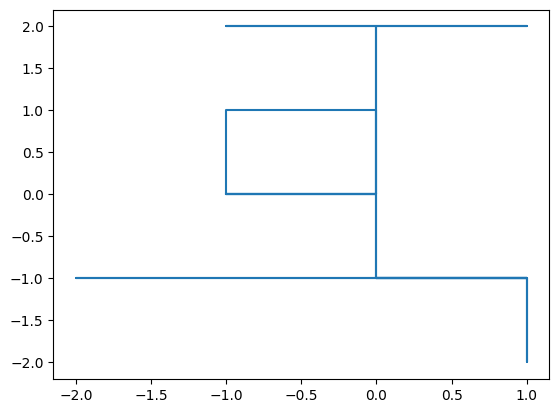

In [4]:
s_t = sample_array[0]
s_x = sample_array[1]
s_y = sample_array[2]
plt.plot(s_x,s_y)

In [5]:
eq_sample_array = equalize(sample_array)



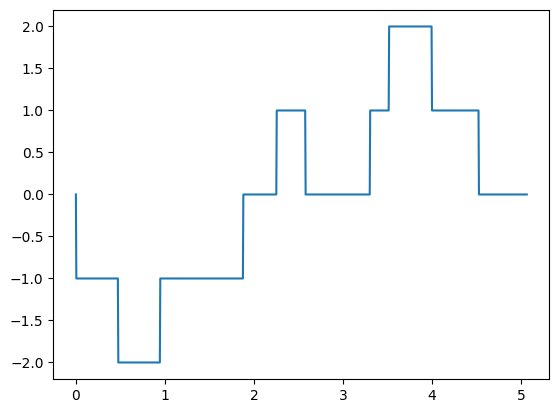

In [6]:
plt.plot(eq_sample_array[0],eq_sample_array[2])

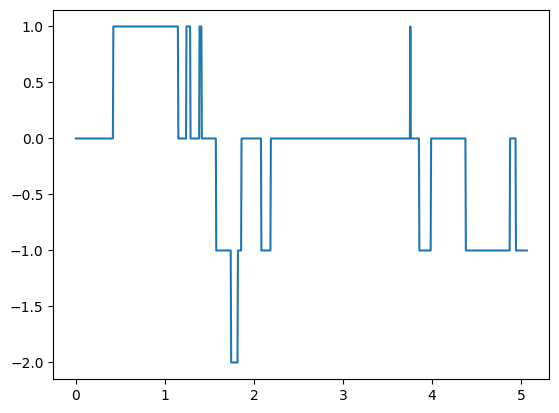

In [7]:
plt.plot(eq_sample_array[0],eq_sample_array[1])

In [8]:
x = [[np.arange(5), np.arange(5)+1, np.arange(5)+2],[np.arange(5)+1, np.arange(5)+2, np.arange(5)+3],[np.arange(5)+2, np.arange(5)+3, np.arange(5)+4],[np.arange(5)+3, np.arange(5)+4, np.arange(5)+5]]
print(x[2][1])

[3 4 5 6 7]


# Creating data

In [9]:
large_data = data_generator(1,1,1,1,10)

In [10]:
large_data_2 = data_generator(1,2,3,4,10)

In [11]:
large_data_3 = data_generator(2,2,4,4,10)

In [12]:
large_data_4 = data_generator(2,3,2,3,10)

In [13]:
averaged_data = average(large_data)
x_avg = averaged_data[0]
y_avg = averaged_data[1]
time_t = large_data[0][0]

In [14]:
averaged_data_2 = average(large_data_2)
x_avg_2 = averaged_data_2[0]
y_avg_2 = averaged_data_2[1]
time_t_2 = large_data_2[0][0]

In [15]:
averaged_data_3 = average(large_data_3)
x_avg_3 = averaged_data_3[0]
y_avg_3 = averaged_data_3[1]
time_t_3 = large_data_3[0][0]

In [16]:
averaged_data_4 = average(large_data_4)
x_avg_4 = averaged_data_4[0]
y_avg_4 = averaged_data_4[1]
time_t_4 = large_data_4[0][0]

# Mean Positions 

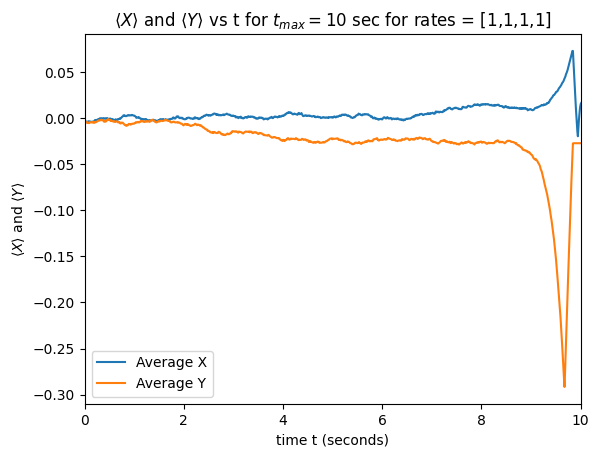

In [17]:
plt.xlim([0,10])
plt.plot(time_t, x_avg, label = "Average X")
plt.plot(time_t, y_avg, label = "Average Y")
plt.legend(loc = "lower left")
plt.title(r"$\langle X\rangle$ and $\langle Y\rangle$ vs t for $t_{max} = 10$ sec for rates = [1,1,1,1]")
plt.xlabel("time t (seconds)")
plt.ylabel(r"$\langle X\rangle$ and $\langle Y\rangle$")
plt.savefig("Mean_pos_1.png", dpi=300, bbox_inches='tight') 

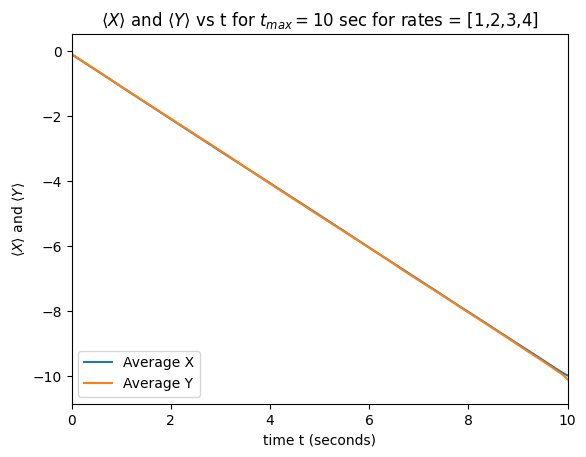

In [18]:
plt.xlim([0,10])
plt.plot(time_t_2, x_avg_2, label = "Average X")
plt.plot(time_t_2, y_avg_2, label = "Average Y")
plt.legend(loc = "lower left")
plt.title(r"$\langle X\rangle$ and $\langle Y\rangle$ vs t for $t_{max} = 10$ sec for rates = [1,2,3,4]")
plt.xlabel("time t (seconds)")
plt.ylabel(r"$\langle X\rangle$ and $\langle Y\rangle$")
plt.savefig("Mean_pos_2.png", dpi=300, bbox_inches='tight') 

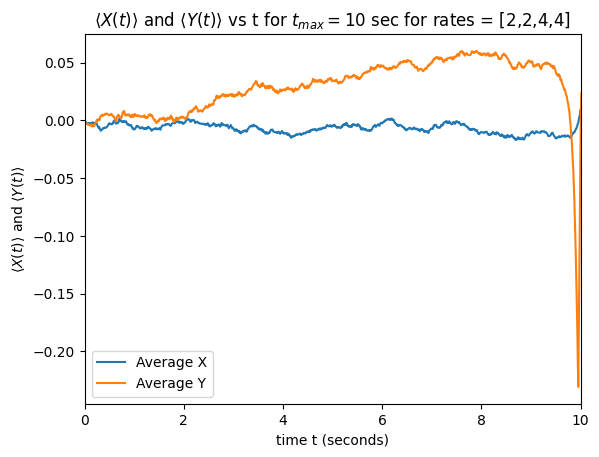

In [19]:
plt.xlim([0,10])
plt.plot(time_t_3, x_avg_3,label = "Average X")
plt.plot(time_t_3, y_avg_3, label = "Average Y")
plt.legend(loc = "lower left")
plt.title(r"$\langle X(t)\rangle$ and $\langle Y(t)\rangle$ vs t for $t_{max} = 10$ sec for rates = [2,2,4,4]")
plt.xlabel("time t (seconds)")
plt.ylabel(r"$\langle X(t)\rangle$ and $\langle Y(t)\rangle$")
plt.savefig("Mean_pos_3.png", dpi=300, bbox_inches='tight') 

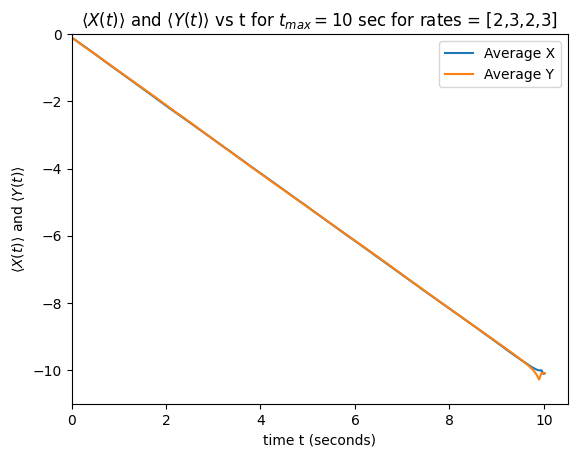

In [20]:
plt.xlim([0,10.5])
plt.ylim([-11,0])
plt.plot(time_t_4, x_avg_4, label = "Average X")
plt.plot(time_t_4, y_avg_4, label = "Average Y")
plt.legend(loc = "upper right")
plt.title(r"$\langle X(t)\rangle$ and $\langle Y(t)\rangle$ vs t for $t_{max} = 10$ sec for rates = [2,3,2,3]")
plt.xlabel("time t (seconds)")
plt.ylabel(r"$\langle X(t)\rangle$ and $\langle Y(t)\rangle$")
plt.savefig("Mean_pos_4.png", dpi=300, bbox_inches='tight') 

# Standard Deviation

In [21]:
sq_averaged_data = squared_average(large_data)
sq_x_avg = sq_averaged_data[0]
sq_y_avg = sq_averaged_data[1]

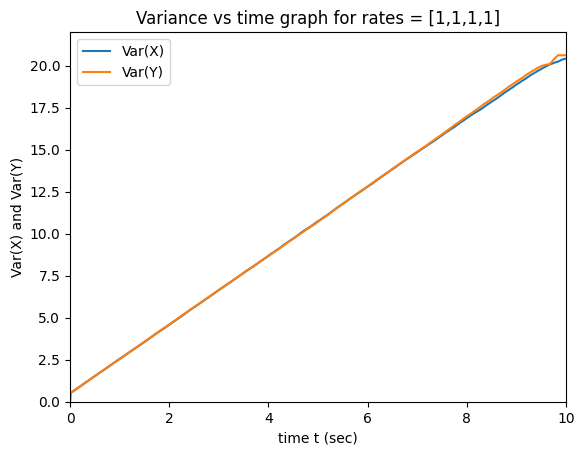

In [22]:
plt.xlim([0,10])
plt.ylim([0,22])
plt.plot(time_t, sq_x_avg-np.power(x_avg,2), label = "Var(X)")
plt.plot(time_t, sq_y_avg-np.power(y_avg,2),label = "Var(Y)")
plt.legend()
plt.xlabel("time t (sec)")
plt.ylabel("Var(X) and Var(Y)")
plt.title("Variance vs time graph for rates = [1,1,1,1]")
plt.savefig("var_1.png", dpi=300, bbox_inches='tight') 

In [23]:
sq_averaged_data_2 = squared_average(large_data_2)
sq_x_avg_2 = sq_averaged_data_2[0]
sq_y_avg_2 = sq_averaged_data_2[1]

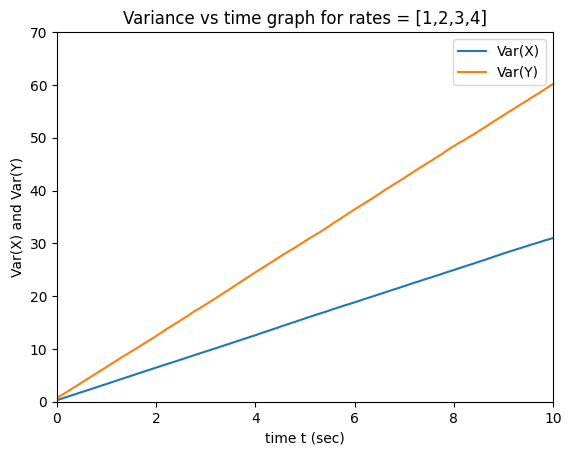

In [24]:
plt.xlim([0,10])
plt.ylim([0,70])
plt.plot(time_t_2, sq_x_avg_2-np.power(x_avg_2,2), label = "Var(X)")
plt.plot(time_t_2, sq_y_avg_2-np.power(y_avg_2,2),label = "Var(Y)")
plt.legend()
plt.xlabel("time t (sec)")
plt.ylabel("Var(X) and Var(Y)")
plt.title("Variance vs time graph for rates = [1,2,3,4]")
plt.savefig("var_2.png", dpi=300, bbox_inches='tight') 

In [25]:
sq_averaged_data_3 = squared_average(large_data_3)
sq_x_avg_3 = sq_averaged_data_3[0]
sq_y_avg_3 = sq_averaged_data_3[1]

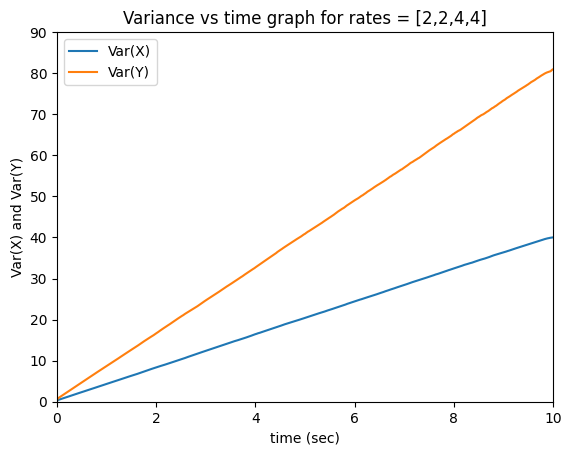

In [26]:
plt.xlim([0,10])
plt.ylim([0,90])
plt.plot(time_t_3, sq_x_avg_3-np.power(x_avg_3,2), label = "Var(X)")
plt.plot(time_t_3, sq_y_avg_3-np.power(y_avg_3,2),label = "Var(Y)")
plt.legend()
plt.xlabel("time (sec)")
plt.ylabel("Var(X) and Var(Y)")
plt.title("Variance vs time graph for rates = [2,2,4,4]")
plt.savefig("var_3.png", dpi=300, bbox_inches='tight') 

In [27]:
sq_averaged_data_4 = squared_average(large_data_4)
sq_x_avg_4 = sq_averaged_data_4[0]
sq_y_avg_4 = sq_averaged_data_4[1]

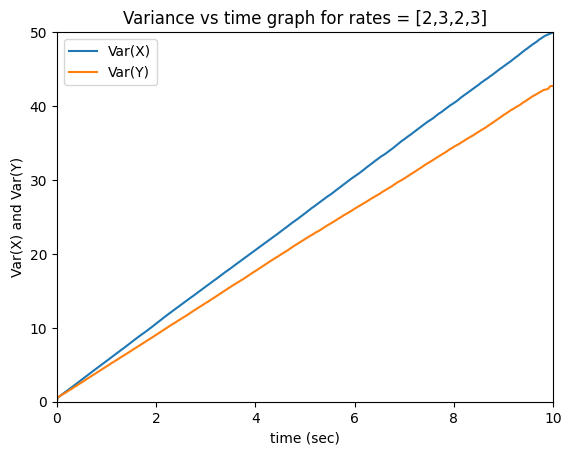

In [28]:
plt.xlim([0,10])
plt.ylim([0,50])
plt.plot(time_t_4, sq_x_avg_4-np.power(x_avg_4,2), label = "Var(X)")
plt.plot(time_t_4, sq_y_avg_4-np.power(y_avg_4,2),label = "Var(Y)")
plt.legend()
plt.xlabel("time (sec)")
plt.ylabel("Var(X) and Var(Y)")
plt.title("Variance vs time graph for rates = [2,3,2,3]")
plt.savefig("var_4.png", dpi=300, bbox_inches='tight') 

# Histogram for Probability distribution function

## Case 1

In [29]:
hist_data_1 = hist_data_generator(1,1,1,1,10)
x_data_hist_1 = hist_data_1[0]
y_data_hist_1 = hist_data_1[1]

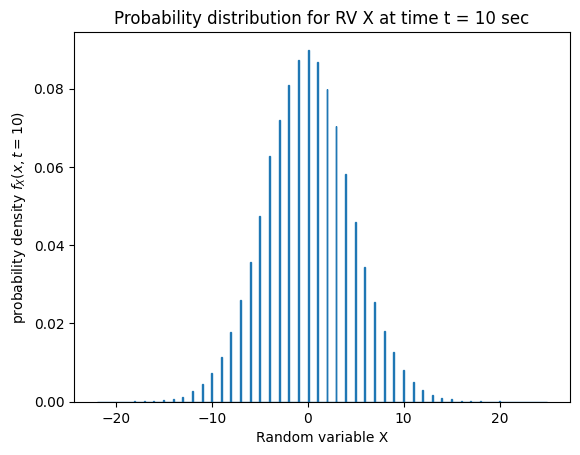

In [30]:
counts_x_1, bins_x_1 = np.histogram(x_data_hist_1, bins = 500)
plt.stairs((counts_x_1/np.sum(counts_x_1)), bins_x_1)
plt.title("Probability distribution for RV X at time t = 10 sec")
plt.ylabel(r"probability density $f_X(x,t=10)$")
plt.xlabel("Random variable X")
plt.savefig("pdf_1_x_10_2d.png", dpi=300, bbox_inches='tight') 

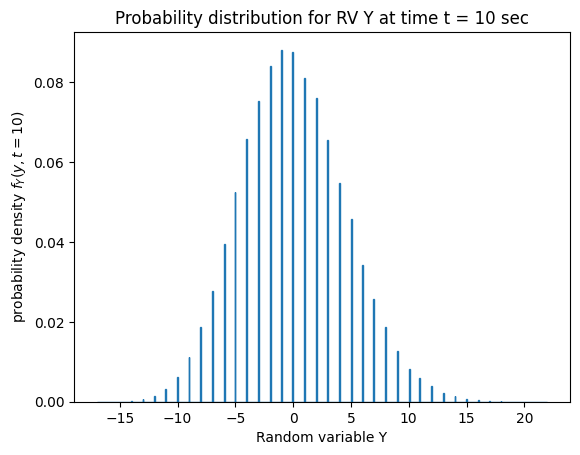

In [31]:
counts_y_1, bins_y_1 = np.histogram(y_data_hist_1, bins = 500)
plt.stairs(counts_y_1/np.sum(counts_y_1), bins_y_1)
plt.title("Probability distribution for RV Y at time t = 10 sec")
plt.ylabel(r"probability density $f_Y(y,t=10)$")
plt.xlabel("Random variable Y")
plt.savefig("pdf_1_y_10_2d.png", dpi=300, bbox_inches='tight') 

In [32]:
hist_data_1_100 = hist_data_generator(1,1,1,1,100)
x_data_hist_1_100 = hist_data_1_100[0]
y_data_hist_1_100 = hist_data_1_100[1]

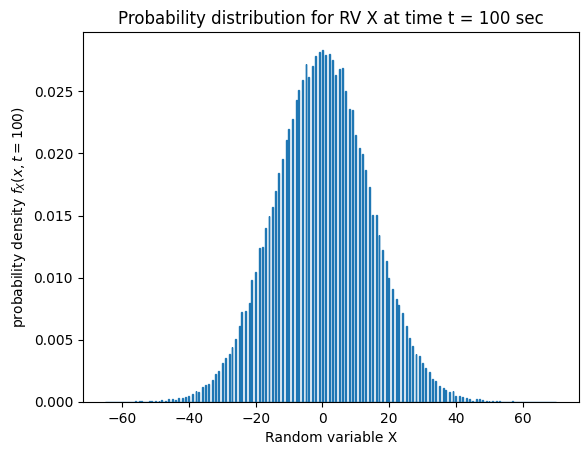

In [33]:
counts_x_100, bins_x_100 = np.histogram(x_data_hist_1_100, bins = 500)
plt.stairs((counts_x_100/np.sum(counts_x_100)), bins_x_100)
plt.title("Probability distribution for RV X at time t = 100 sec")
plt.ylabel(r"probability density $f_X(x,t=100)$")
plt.xlabel("Random variable X")
plt.savefig("pdf_1_x_100_2d.png", dpi=300, bbox_inches='tight') 

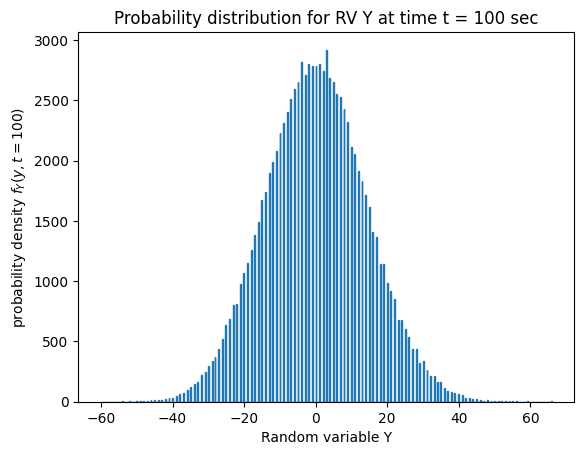

In [34]:
counts_y_100, bins_y_100 = np.histogram(y_data_hist_1_100, bins = 500)
plt.stairs(counts_y_100, bins_y_100)
plt.title("Probability distribution for RV Y at time t = 100 sec")
plt.ylabel(r"probability density $f_Y(y,t=100)$")
plt.xlabel("Random variable Y")
plt.savefig("pdf_1_y_100_2d.png", dpi=300, bbox_inches='tight') 

In [35]:
hist_data_1_1000 = hist_data_generator(1,1,1,1,1000)
x_data_hist_1_1000 = hist_data_1_1000[0]
y_data_hist_1_1000 = hist_data_1_1000[1]

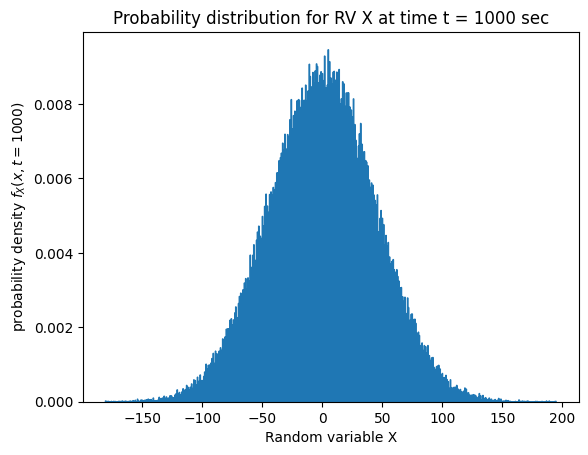

In [36]:
counts_x_1000, bins_x_1000 = np.histogram(x_data_hist_1_1000, bins = 1000)
plt.stairs(counts_x_1000/np.sum(counts_x_1000), bins_x_1000)
plt.title("Probability distribution for RV X at time t = 1000 sec")
plt.ylabel(r"probability density $f_X(x,t=1000)$")
plt.xlabel("Random variable X")
plt.savefig("pdf_1_x_1000_2d.png", dpi=300, bbox_inches='tight') 

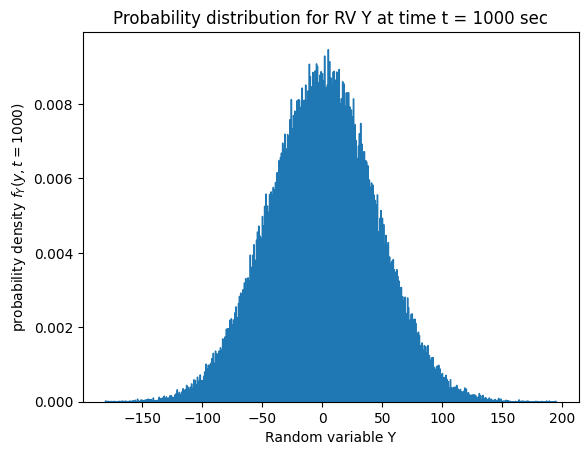

In [37]:
counts_y_1000, bins_y_1000 = np.histogram(x_data_hist_1_1000, bins = 1000)
plt.stairs(counts_y_1000/np.sum(counts_y_1000), bins_y_1000)
plt.title("Probability distribution for RV Y at time t = 1000 sec")
plt.ylabel(r"probability density $f_Y(y,t=1000)$")
plt.xlabel("Random variable Y")
plt.savefig("pdf_1_y_1000_2d.png", dpi=300, bbox_inches='tight') 

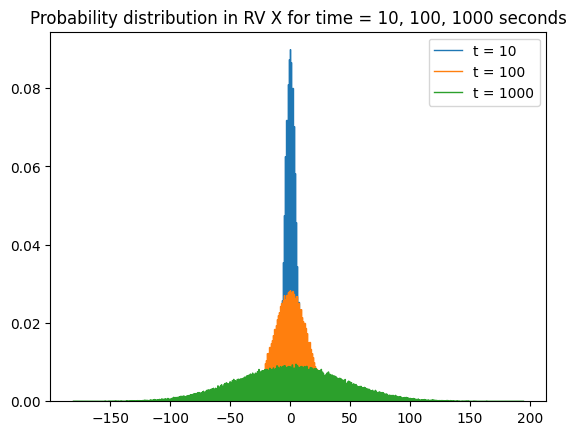

In [38]:
plt.title("Probability distribution in RV X for time = 10, 100, 1000 seconds")

plt.stairs((counts_x_1/np.sum(counts_x_1)), bins_x_1, label = "t = 10")
plt.stairs((counts_x_100/np.sum(counts_x_100)), bins_x_100, label = "t = 100")
plt.stairs((counts_x_1000/np.sum(counts_x_1000)), bins_x_1000, label = "t = 1000")

plt.legend(loc= "upper right")
plt.savefig("pdf_1_xvst_2d.png", dpi=300, bbox_inches='tight') 

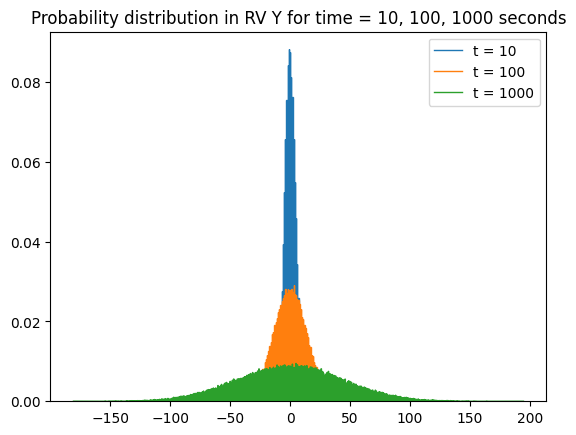

In [39]:
plt.title("Probability distribution in RV Y for time = 10, 100, 1000 seconds")

plt.stairs((counts_y_1/np.sum(counts_y_1)), bins_y_1, label = "t = 10")
plt.stairs((counts_y_100/np.sum(counts_y_100)), bins_y_100, label = "t = 100")
plt.stairs((counts_y_1000/np.sum(counts_y_1000)), bins_y_1000, label = "t = 1000")
plt.legend(loc= "upper right")
plt.savefig("pdf_1_yvst_2d.png", dpi=300, bbox_inches='tight') 

In [40]:
#print(bins_x_1)
#for i in range(len(bins_x_1)):
#    if (bins_x_1[i]<=0 and bins_x_1[i+1]>=0):
#        print(i+1)
#        break

#for i in range(len(bins_x_100)):
#    if (bins_x_100[i]<=0 and bins_x_100[i+1]>=0):
#        print(i+1)
#        break

#for i in range(len(bins_x_1000)):
#    if (bins_x_1000[i]<=0 and bins_x_1000[i+1]>=0):
#        print(i+1)
#        break


In [41]:
#x_axis = [0,10,100,1000]
#y_axis = [1,counts_x_1[228]/np.sum(counts_x_1), counts_x_100[249]/np.sum(counts_x_100), counts_x_1000[485]/np.sum(counts_x_1000)]
#plt.plot(x_axis, y_axis)
#plt.plot(np.linspace(0,100,100),np.exp((-1)*np.linspace(0,100,100)))

## Case 2

In [42]:
hist_data_2_100 = hist_data_generator(1,2,3,4,100)
x_data_hist_2_100 = hist_data_2_100[0]
y_data_hist_2_100 = hist_data_2_100[1]

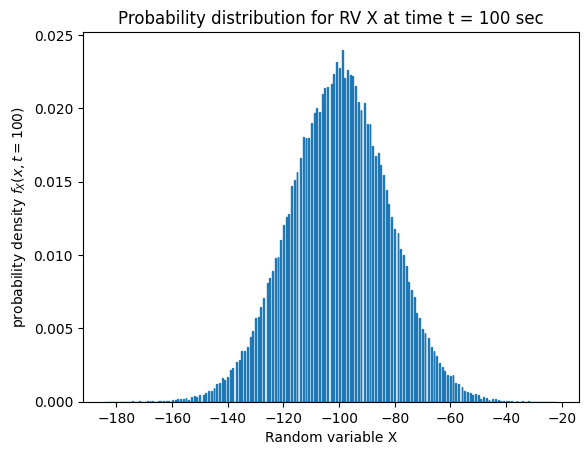

In [43]:
counts_x_200, bins_x_200 = np.histogram(x_data_hist_2_100, bins = 500)
plt.stairs(counts_x_200/np.sum(counts_x_200), bins_x_200)
plt.title("Probability distribution for RV X at time t = 100 sec")
plt.ylabel(r"probability density $f_X(x,t=100)$")
plt.xlabel("Random variable X")
plt.savefig("pdf_2_x_100_2d.png", dpi=300, bbox_inches='tight') 

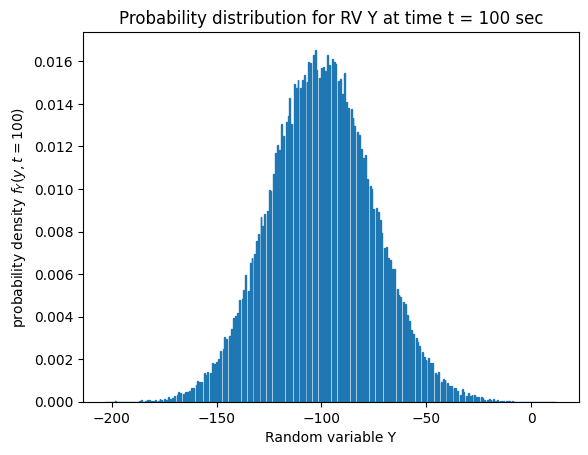

In [44]:
counts_y_200, bins_y_200 = np.histogram(y_data_hist_2_100, bins = 500)
plt.stairs(counts_y_200/np.sum(counts_y_200), bins_y_200)
plt.title("Probability distribution for RV Y at time t = 100 sec")
plt.ylabel(r"probability density $f_Y(y,t=100)$")
plt.xlabel("Random variable Y")
plt.savefig("pdf_2_y_100_2d.png", dpi=300, bbox_inches='tight') 

In [45]:
hist_data_2_1000 = hist_data_generator(1,2,3,4,1000)
x_data_hist_2_1000 = hist_data_2_1000[0]
y_data_hist_2_1000 = hist_data_2_1000[1]

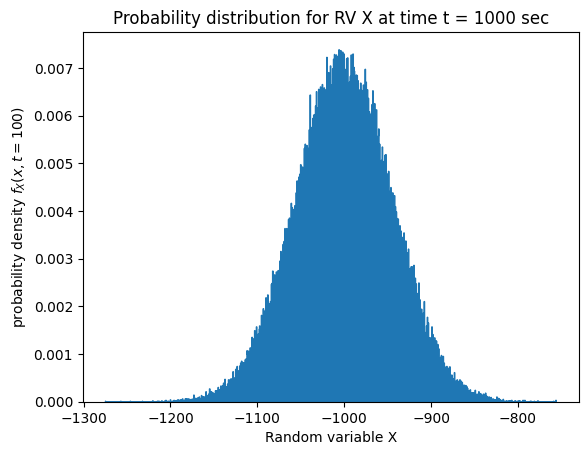

In [46]:
counts_x_2000, bins_x_2000 = np.histogram(x_data_hist_2_1000, bins = 1000)
plt.stairs(counts_x_2000/np.sum(counts_x_2000), bins_x_2000)
plt.title("Probability distribution for RV X at time t = 1000 sec")
plt.ylabel(r"probability density $f_X(x,t=100)$")
plt.xlabel("Random variable X")
plt.savefig("pdf_2_x_1000_2d.png", dpi=300, bbox_inches='tight') 

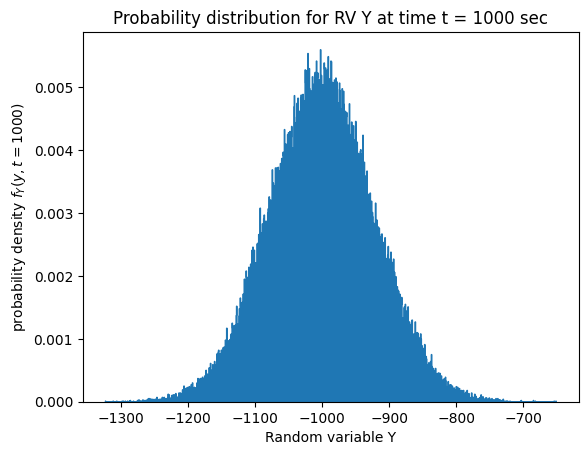

In [47]:
counts_y_2000, bins_y_2000 = np.histogram(y_data_hist_2_1000, bins = 1000)
plt.stairs(counts_y_2000/np.sum(counts_y_2000), bins_y_2000)
plt.title("Probability distribution for RV Y at time t = 1000 sec")
plt.ylabel(r"probability density $f_Y(y,t=1000)$")
plt.xlabel("Random variable Y")
plt.savefig("pdf_2_y_1000_2d.png", dpi=300, bbox_inches='tight') 

In [48]:
hist_data_2 = hist_data_generator(1,2,3,4,10)
x_data_hist_2 = hist_data_2[0]
y_data_hist_2 = hist_data_2[1]

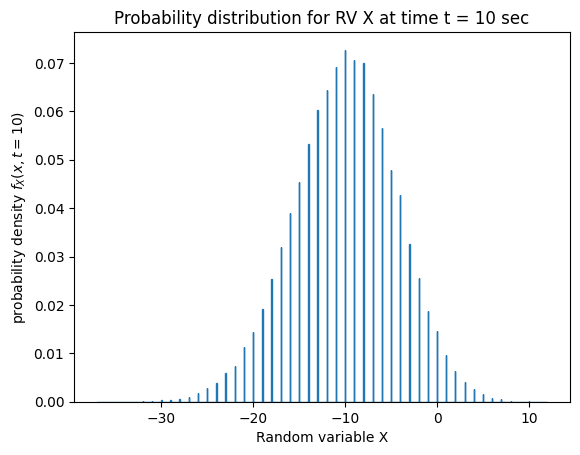

In [49]:
counts_x_2, bins_x_2 = np.histogram(x_data_hist_2, bins = 500)
plt.stairs(counts_x_2/np.sum(counts_x_2), bins_x_2)
plt.title("Probability distribution for RV X at time t = 10 sec")
plt.ylabel(r"probability density $f_X(x,t=10)$")
plt.xlabel("Random variable X")
plt.savefig("pdf_2_x_10_2d.png", dpi=300, bbox_inches='tight') 

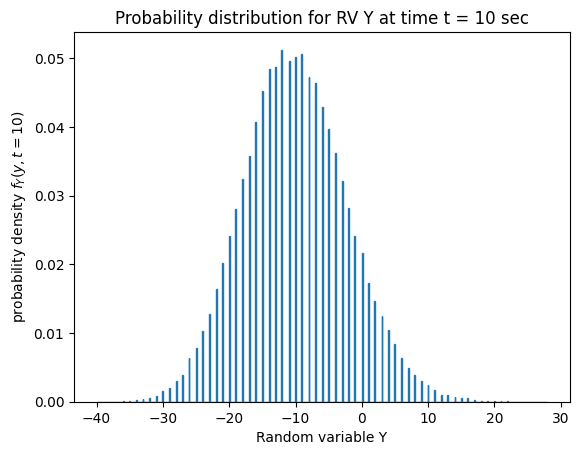

In [50]:
counts_y_2, bins_y_2 = np.histogram(y_data_hist_2, bins = 500)
plt.stairs(counts_y_2/np.sum(counts_y_2), bins_y_2)
plt.title("Probability distribution for RV Y at time t = 10 sec")
plt.ylabel(r"probability density $f_Y(y,t=10)$")
plt.xlabel("Random variable Y")
plt.savefig("pdf_2_y_10_2d.png", dpi=300, bbox_inches='tight') 

## Case 3 

In [51]:
hist_data_3_100 = hist_data_generator(2,2,4,4,100)
x_data_hist_3_100 = hist_data_3_100[0]
y_data_hist_3_100 = hist_data_3_100[1]

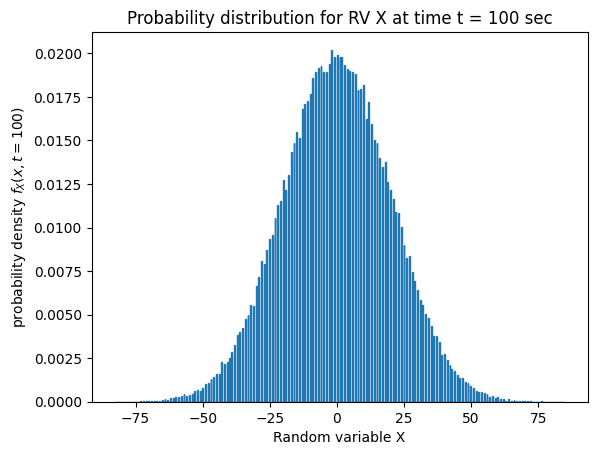

In [52]:
counts_x_300, bins_x_300 = np.histogram(x_data_hist_3_100, bins = 500)
plt.stairs(counts_x_300/np.sum(counts_x_300), bins_x_300)
plt.title("Probability distribution for RV X at time t = 100 sec")
plt.ylabel(r"probability density $f_X(x,t=100)$")
plt.xlabel("Random variable X")
plt.savefig("pdf_3_x_100_2d.png", dpi=300, bbox_inches='tight') 

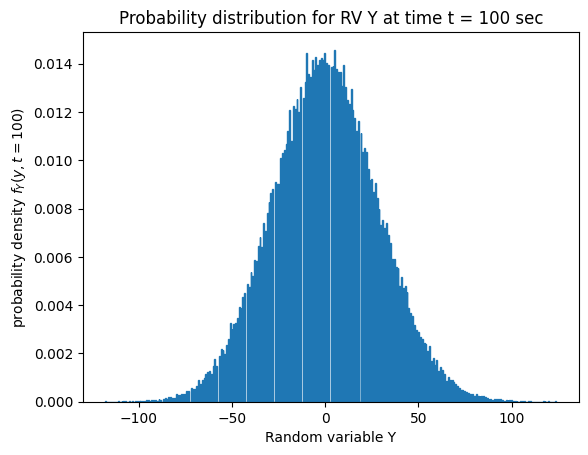

In [53]:
counts_y_300, bins_y_300 = np.histogram(y_data_hist_3_100, bins = 500)
plt.stairs(counts_y_300/np.sum(counts_y_300), bins_y_300)
plt.title("Probability distribution for RV Y at time t = 100 sec")
plt.ylabel(r"probability density $f_Y(y,t=100)$")
plt.xlabel("Random variable Y")
plt.savefig("pdf_3_y_100_2d.png", dpi=300, bbox_inches='tight') 

In [54]:
hist_data_3_1000 = hist_data_generator(2,2,4,4,1000)
x_data_hist_3_1000 = hist_data_3_1000[0]
y_data_hist_3_1000 = hist_data_3_1000[1]

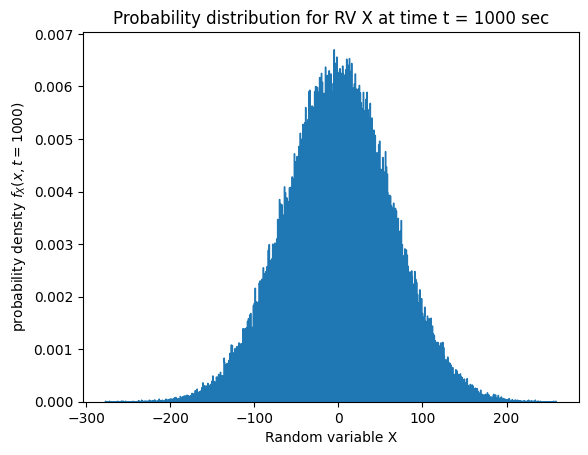

In [55]:
counts_x_3000, bins_x_3000 = np.histogram(x_data_hist_3_1000, bins = 1000)
plt.stairs(counts_x_3000/np.sum(counts_x_3000), bins_x_3000)
plt.title("Probability distribution for RV X at time t = 1000 sec")
plt.ylabel(r"probability density $f_X(x,t=1000)$")
plt.xlabel("Random variable X")
plt.savefig("pdf_3_x_1000_2d.png", dpi=300, bbox_inches='tight') 

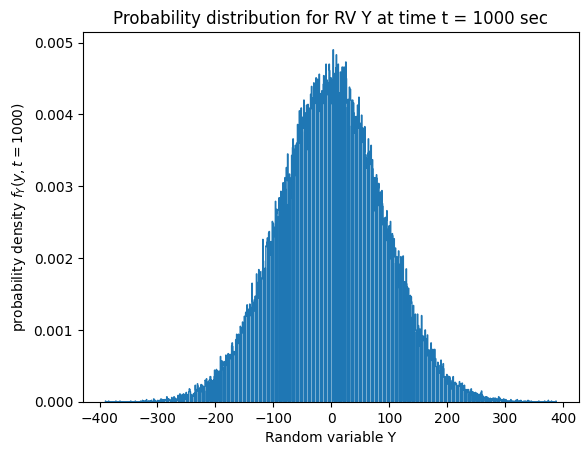

In [56]:
counts_y_3000, bins_y_3000 = np.histogram(y_data_hist_3_1000, bins = 1000)
plt.stairs(counts_y_3000/np.sum(counts_y_3000), bins_y_3000)
plt.title("Probability distribution for RV Y at time t = 1000 sec")
plt.ylabel(r"probability density $f_Y(y,t=1000)$")
plt.xlabel("Random variable Y")
plt.savefig("pdf_3_y_1000_2d.png", dpi=300, bbox_inches='tight') 

In [57]:
hist_data_3 = hist_data_generator(2,2,4,4,10)
x_data_hist_3 = hist_data_3[0]
y_data_hist_3 = hist_data_3[1]

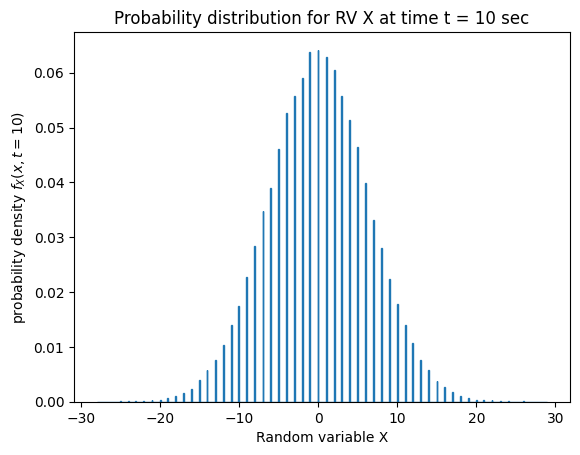

In [58]:
counts_x_3, bins_x_3 = np.histogram(x_data_hist_3, bins = 500)
plt.stairs(counts_x_3/np.sum(counts_x_3), bins_x_3)
plt.title("Probability distribution for RV X at time t = 10 sec")
plt.ylabel(r"probability density $f_X(x,t=10)$")
plt.xlabel("Random variable X")
plt.savefig("pdf_3_x_10_2d.png", dpi=300, bbox_inches='tight') 

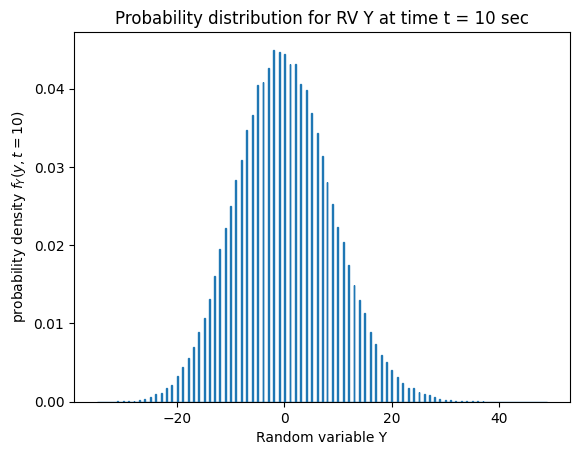

In [59]:
counts_y_3, bins_y_3 = np.histogram(y_data_hist_3, bins = 500)
plt.stairs(counts_y_3/np.sum(counts_y_3), bins_y_3)
plt.title("Probability distribution for RV Y at time t = 10 sec")
plt.ylabel(r"probability density $f_Y(y,t=10)$")
plt.xlabel("Random variable Y")
plt.savefig("pdf_3_y_10_2d.png", dpi=300, bbox_inches='tight') 

## Case 4

In [60]:
hist_data_4_100 = hist_data_generator(2,3,2,3,100)
x_data_hist_4_100 = hist_data_4_100[0]
y_data_hist_4_100 = hist_data_4_100[1]

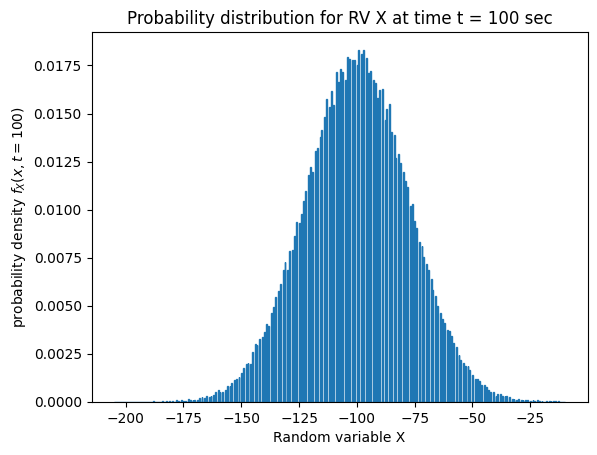

In [61]:
counts_x_400, bins_x_400 = np.histogram(x_data_hist_4_100, bins = 500)
plt.stairs(counts_x_400/np.sum(counts_x_400), bins_x_400)
plt.title("Probability distribution for RV X at time t = 100 sec")
plt.ylabel(r"probability density $f_X(x,t=100)$")
plt.xlabel("Random variable X")
plt.savefig("pdf_4_x_100_2d.png", dpi=300, bbox_inches='tight') 

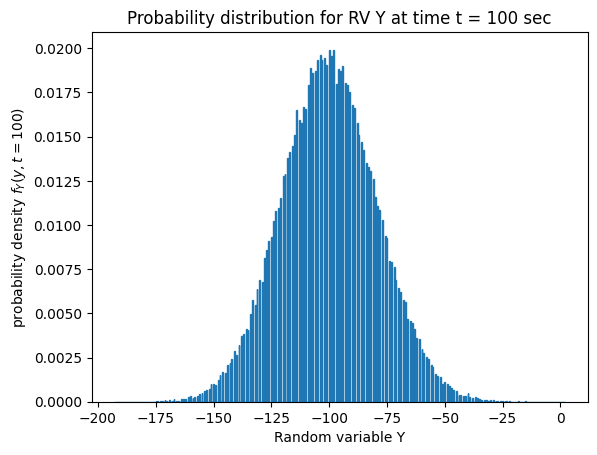

In [62]:
counts_y_400, bins_y_400 = np.histogram(y_data_hist_4_100, bins = 500)
plt.stairs(counts_y_400/np.sum(counts_y_400), bins_y_400)
plt.title("Probability distribution for RV Y at time t = 100 sec")
plt.ylabel(r"probability density $f_Y(y,t=100)$")
plt.xlabel("Random variable Y")
plt.savefig("pdf_4_y_100_2d.png", dpi=300, bbox_inches='tight') 

In [64]:
hist_data_4_1000 = hist_data_generator(2,3,2,3,1000)
x_data_hist_4_1000 = hist_data_4_1000[0]
y_data_hist_4_1000 = hist_data_4_1000[1]

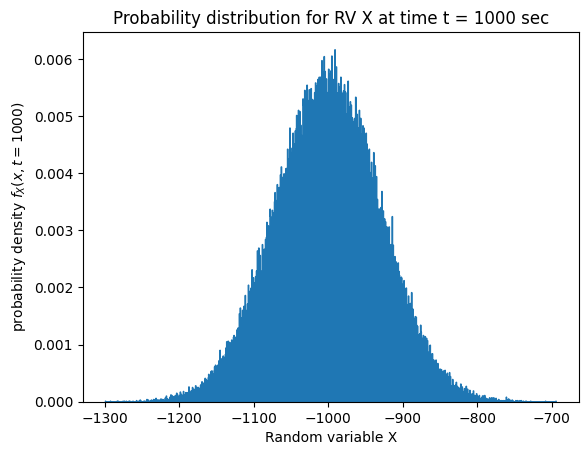

In [65]:
counts_x_4000, bins_x_4000 = np.histogram(x_data_hist_4_1000, bins = 1000)
plt.stairs(counts_x_4000/np.sum(counts_x_4000), bins_x_4000)
plt.title("Probability distribution for RV X at time t = 1000 sec")
plt.ylabel(r"probability density $f_X(x,t=1000)$")
plt.xlabel("Random variable X")
plt.savefig("pdf_4_x_1000_2d.png", dpi=300, bbox_inches='tight') 

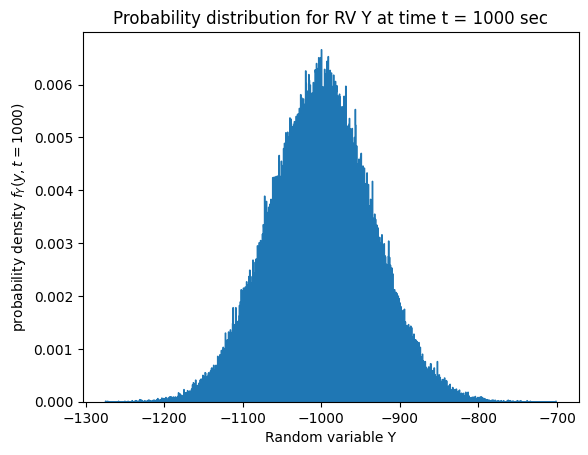

In [66]:
counts_y_4000, bins_y_4000 = np.histogram(y_data_hist_4_1000, bins = 1000)
plt.stairs(counts_y_4000/np.sum(counts_y_4000), bins_y_4000)
plt.title("Probability distribution for RV Y at time t = 1000 sec")
plt.ylabel(r"probability density $f_Y(y,t=1000)$")
plt.xlabel("Random variable Y")
plt.savefig("pdf_4_y_1000_2d.png", dpi=300, bbox_inches='tight') 

In [67]:
hist_data_4 = hist_data_generator(2,3,2,3,10)
x_data_hist_4 = hist_data_4[0]
y_data_hist_4 = hist_data_4[1]

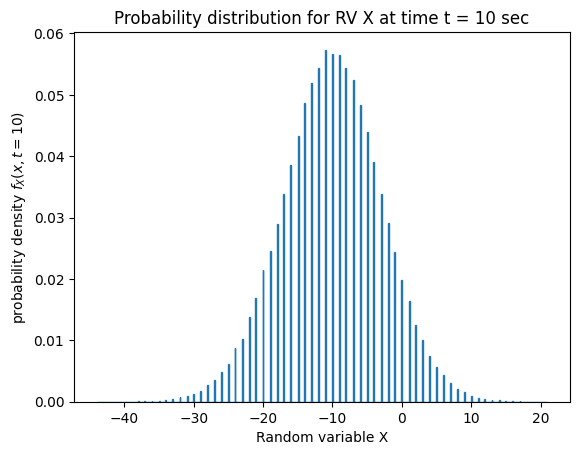

In [68]:
counts_x_4, bins_x_4 = np.histogram(x_data_hist_4, bins = 500)
plt.stairs(counts_x_4/np.sum(counts_x_4), bins_x_4)
plt.title("Probability distribution for RV X at time t = 10 sec")
plt.ylabel(r"probability density $f_X(x,t=10)$")
plt.xlabel("Random variable X")
plt.savefig("pdf_4_x_10_2d.png", dpi=300, bbox_inches='tight') 

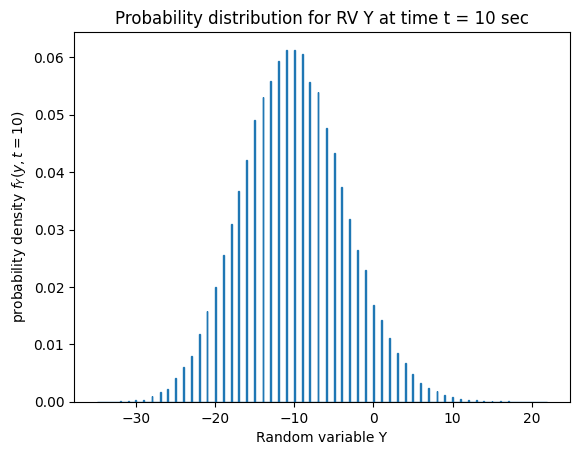

In [69]:
counts_y_4, bins_y_4 = np.histogram(y_data_hist_4, bins = 500)
plt.stairs(counts_y_4/np.sum(counts_y_4), bins_y_4)
plt.title("Probability distribution for RV Y at time t = 10 sec")
plt.ylabel(r"probability density $f_Y(y,t=10)$")
plt.xlabel("Random variable Y")
plt.savefig("pdf_4_x_10_2d.png", dpi=300, bbox_inches='tight') 

## Case 1

In [70]:
#abbb = plt.hist2d(x_data_hist_1_100, y_data_hist_1_100, bins = 100)

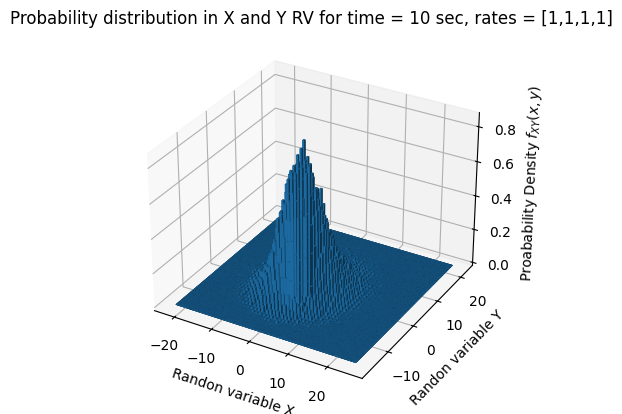

In [71]:
fig_1 = plt.figure()
ax_1 = fig_1.add_subplot(projection='3d')
hist_1, xedges_1, yedges_1 = np.histogram2d(x_data_hist_1, y_data_hist_1, bins=200)

# Construct arrays for the anchor positions of the 16 bars.
xpos_1, ypos_1 = np.meshgrid(xedges_1[:-1] , yedges_1[:-1], indexing="ij")
xpos_1 = xpos_1.ravel()
ypos_1 = ypos_1.ravel()
zpos_1 = 0

# Construct arrays with the dimensions for the 16 bars.
dx_1 = dy_1 = 0.5 * np.ones_like(zpos_1)
dz_1 = hist_1.ravel()/1000

ax_1.bar3d(xpos_1, ypos_1, zpos_1, dx_1, dy_1, dz_1, zsort='average')
ax_1.set_title("Probability distribution in X and Y RV for time = 10 sec, rates = [1,1,1,1]")
ax_1.set_xlabel("Randon variable X")
ax_1.set_ylabel("Randon variable Y")
ax_1.set_zlabel(r"Proabability Density $f_{XY}(x,y)$")
plt.show()
ax_1.get_figure().savefig('pdf_1_10_3d.png', dpi=300, bbox_inches='tight')

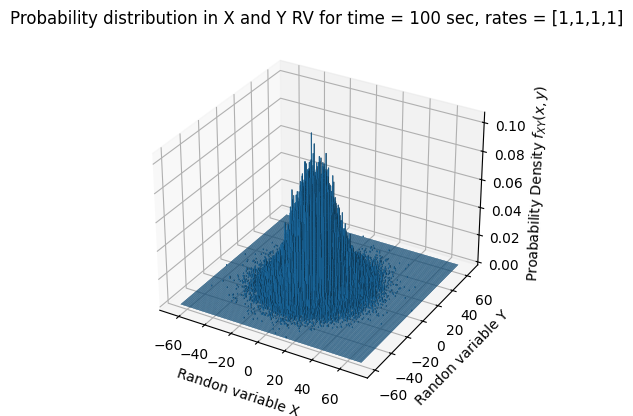

In [72]:
fig_1_100 = plt.figure()
ax_1_100 = fig_1_100.add_subplot(projection='3d')
hist_1_100, xedges_1_100, yedges_1_100 = np.histogram2d(x_data_hist_1_100, y_data_hist_1_100, bins=200)

# Construct arrays for the anchor positions of the 16 bars.
xpos_1_100, ypos_1_100 = np.meshgrid(xedges_1_100[:-1] , yedges_1_100[:-1], indexing="ij")
xpos_1_100 = xpos_1_100.ravel()
ypos_1_100 = ypos_1_100.ravel()
zpos_1_100 = 0

# Construct arrays with the dimensions for the 16 bars.
dx_1_100 = dy_1_100 = 0.5 * np.ones_like(zpos_1_100)
dz_1_100 = hist_1_100.ravel()/1000

ax_1_100.bar3d(xpos_1_100, ypos_1_100, zpos_1_100, dx_1_100, dy_1_100, dz_1_100, zsort='average')
ax_1_100.set_title("Probability distribution in X and Y RV for time = 100 sec, rates = [1,1,1,1]")
ax_1_100.set_xlabel("Randon variable X")
ax_1_100.set_ylabel("Randon variable Y")
ax_1_100.set_zlabel(r"Proabability Density $f_{XY}(x,y)$")
plt.show()
ax_1_100.get_figure().savefig('pdf_1_100_3d.png', dpi=300, bbox_inches='tight')

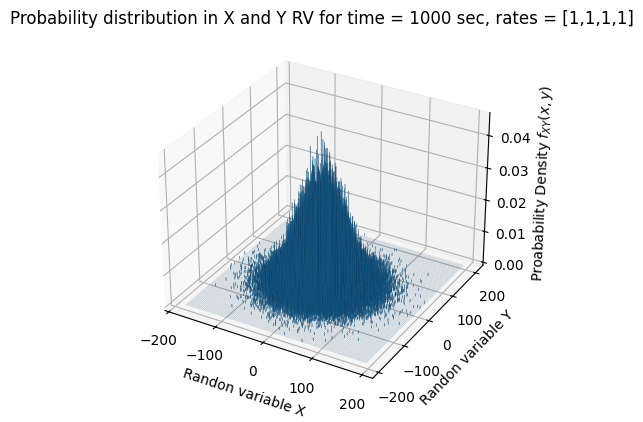

In [73]:
fig_1_1000 = plt.figure()
ax_1_1000 = fig_1_1000.add_subplot(projection='3d')
hist_1_1000, xedges_1_1000, yedges_1_1000 = np.histogram2d(x_data_hist_1_1000, y_data_hist_1_1000, bins=200)

# Construct arrays for the anchor positions of the 16 bars.
xpos_1_1000, ypos_1_1000 = np.meshgrid(xedges_1_1000[:-1] , yedges_1_1000[:-1], indexing="ij")
xpos_1_1000 = xpos_1_1000.ravel()
ypos_1_1000 = ypos_1_1000.ravel()
zpos_1_1000 = 0

# Construct arrays with the dimensions for the 16 bars.
dx_1_1000 = dy_1_1000 = 0.5 * np.ones_like(zpos_1_1000)
dz_1_1000 = hist_1_1000.ravel()/1000

ax_1_1000.bar3d(xpos_1_1000, ypos_1_1000, zpos_1_1000, dx_1_1000, dy_1_1000, dz_1_1000, zsort='average')
ax_1_1000.set_title("Probability distribution in X and Y RV for time = 1000 sec, rates = [1,1,1,1]")
ax_1_1000.set_xlabel("Randon variable X")
ax_1_1000.set_ylabel("Randon variable Y")
ax_1_1000.set_zlabel(r"Proabability Density $f_{XY}(x,y)$")
plt.show()
ax_1_1000.get_figure().savefig('pdf_1_1000_3d.png', dpi=300, bbox_inches='tight')

## Case 2

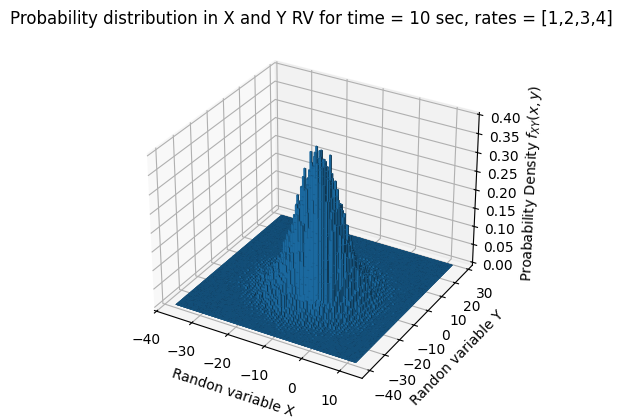

In [74]:
fig_2 = plt.figure()
ax_2 = fig_2.add_subplot(projection='3d')
hist_2, xedges_2, yedges_2 = np.histogram2d(x_data_hist_2, y_data_hist_2, bins=200)

# Construct arrays for the anchor positions of the 16 bars.
xpos_2, ypos_2 = np.meshgrid(xedges_2[:-1] , yedges_2[:-1], indexing="ij")
xpos_2 = xpos_2.ravel()
ypos_2 = ypos_2.ravel()
zpos_2 = 0

# Construct arrays with the dimensions for the 16 bars.
dx_2 = dy_2 = 0.5 * np.ones_like(zpos_2)
dz_2 = hist_2.ravel()/1000

ax_2.bar3d(xpos_2, ypos_2, zpos_2, dx_2, dy_2, dz_2, zsort='average')
ax_2.set_title("Probability distribution in X and Y RV for time = 10 sec, rates = [1,2,3,4]")
ax_2.set_xlabel("Randon variable X")
ax_2.set_ylabel("Randon variable Y")
ax_2.set_zlabel(r"Proabability Density $f_{XY}(x,y)$")
plt.show()
ax_2.get_figure().savefig('pdf_2_10_3d.png', dpi=300, bbox_inches='tight')

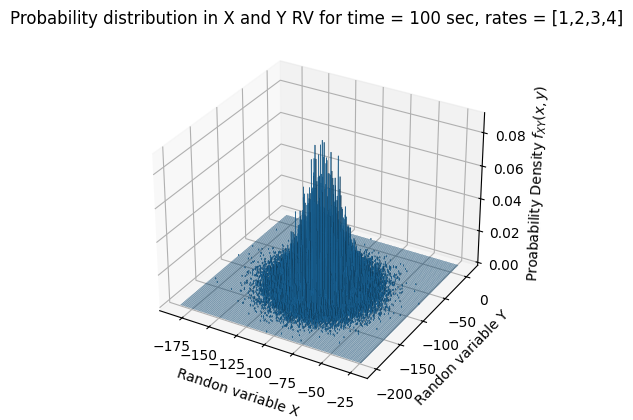

In [75]:
fig_2_100 = plt.figure()
ax_2_100 = fig_2_100.add_subplot(projection='3d')
hist_2_100, xedges_2_100, yedges_2_100 = np.histogram2d(x_data_hist_2_100, y_data_hist_2_100, bins=200)

# Construct arrays for the anchor positions of the 16 bars.
xpos_2_100, ypos_2_100 = np.meshgrid(xedges_2_100[:-1] , yedges_2_100[:-1], indexing="ij")
xpos_2_100 = xpos_2_100.ravel()
ypos_2_100 = ypos_2_100.ravel()
zpos_2_100 = 0

# Construct arrays with the dimensions for the 16 bars.
dx_2_100 = dy_2_100 = 0.5 * np.ones_like(zpos_2_100)
dz_2_100 = hist_2_100.ravel()/1000

ax_2_100.bar3d(xpos_2_100, ypos_2_100, zpos_2_100, dx_2_100, dy_2_100, dz_2_100, zsort='average')
ax_2_100.set_title("Probability distribution in X and Y RV for time = 100 sec, rates = [1,2,3,4]")
ax_2_100.set_xlabel("Randon variable X")
ax_2_100.set_ylabel("Randon variable Y")
ax_2_100.set_zlabel(r"Proabability Density $f_{XY}(x,y)$")
plt.show
ax_2_100.get_figure().savefig('pdf_2_100_3d.png', dpi=300, bbox_inches='tight')

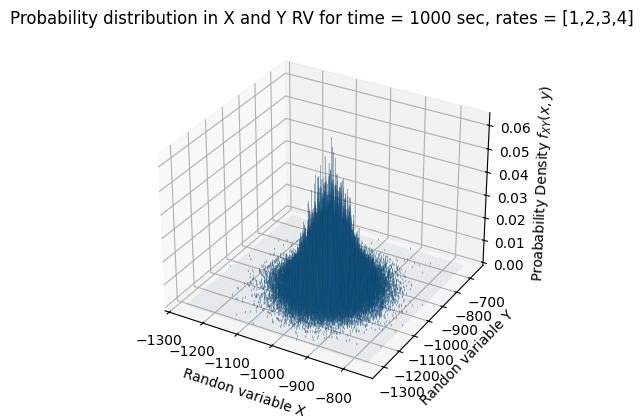

In [76]:
fig_2_1000 = plt.figure()
ax_2_1000 = fig_2_1000.add_subplot(projection='3d')
hist_2_1000, xedges_2_1000, yedges_2_1000 = np.histogram2d(x_data_hist_2_1000, y_data_hist_2_1000, bins=200)

# Construct arrays for the anchor positions of the 16 bars.
xpos_2_1000, ypos_2_1000 = np.meshgrid(xedges_2_1000[:-1] , yedges_2_1000[:-1], indexing="ij")
xpos_2_1000 = xpos_2_1000.ravel()
ypos_2_1000 = ypos_2_1000.ravel()
zpos_2_1000 = 0

# Construct arrays with the dimensions for the 16 bars.
dx_2_1000 = dy_2_1000 = 0.5 * np.ones_like(zpos_2_1000)
dz_2_1000 = hist_2_1000.ravel()/1000

ax_2_1000.bar3d(xpos_2_1000, ypos_2_1000, zpos_2_1000, dx_2_1000, dy_2_1000, dz_2_1000, zsort='average')
ax_2_1000.set_title("Probability distribution in X and Y RV for time = 1000 sec, rates = [1,2,3,4]")
ax_2_1000.set_xlabel("Randon variable X")
ax_2_1000.set_ylabel("Randon variable Y")
ax_2_1000.set_zlabel(r"Proabability Density $f_{XY}(x,y)$")
plt.show()
ax_2_1000.get_figure().savefig('pdf_2_1000_3d.png', dpi=300, bbox_inches='tight')

## Case 3

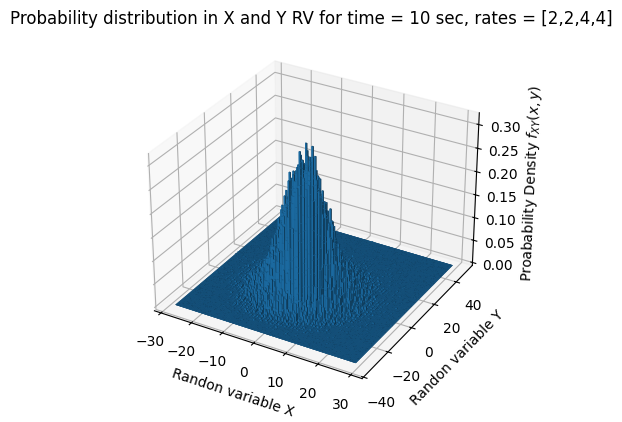

In [77]:
fig_3 = plt.figure()
ax_3 = fig_3.add_subplot(projection='3d')
hist_3, xedges_3, yedges_3 = np.histogram2d(x_data_hist_3, y_data_hist_3, bins=200)

# Construct arrays for the anchor positions of the 16 bars.
xpos_3, ypos_3 = np.meshgrid(xedges_3[:-1] , yedges_3[:-1], indexing="ij")
xpos_3 = xpos_3.ravel()
ypos_3 = ypos_3.ravel()
zpos_3 = 0

# Construct arrays with the dimensions for the 16 bars.
dx_3 = dy_3 = 0.5 * np.ones_like(zpos_3)
dz_3 = hist_3.ravel()/1000

ax_3.bar3d(xpos_3, ypos_3, zpos_3, dx_3, dy_3, dz_3, zsort='average')
ax_3.set_title("Probability distribution in X and Y RV for time = 10 sec, rates = [2,2,4,4]")
ax_3.set_xlabel("Randon variable X")
ax_3.set_ylabel("Randon variable Y")
ax_3.set_zlabel(r"Proabability Density $f_{XY}(x,y)$")
plt.show()
ax_3.get_figure().savefig('pdf_3_10_3d.png', dpi=300, bbox_inches='tight')

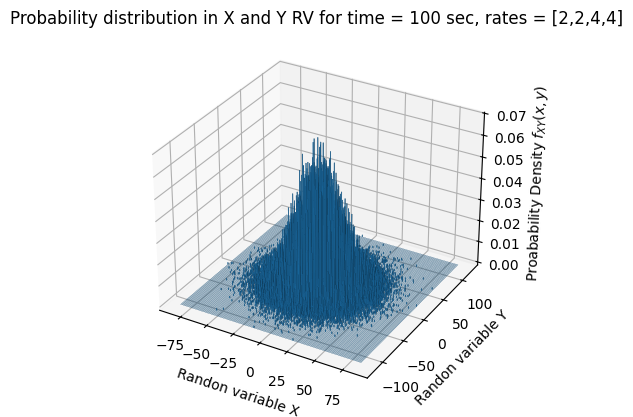

In [78]:
fig_3_100 = plt.figure()
ax_3_100 = fig_3_100.add_subplot(projection='3d')
hist_3_100, xedges_3_100, yedges_3_100 = np.histogram2d(x_data_hist_3_100, y_data_hist_3_100, bins=200)

# Construct arrays for the anchor positions of the 16 bars.
xpos_3_100, ypos_3_100 = np.meshgrid(xedges_3_100[:-1] , yedges_3_100[:-1], indexing="ij")
xpos_3_100 = xpos_3_100.ravel()
ypos_3_100 = ypos_3_100.ravel()
zpos_3_100 = 0

# Construct arrays with the dimensions for the 16 bars.
dx_3_100 = dy_3_100 = 0.5 * np.ones_like(zpos_3_100)
dz_3_100 = hist_3_100.ravel()/1000

ax_3_100.bar3d(xpos_3_100, ypos_3_100, zpos_3_100, dx_3_100, dy_3_100, dz_3_100, zsort='average')
ax_3_100.set_title("Probability distribution in X and Y RV for time = 100 sec, rates = [2,2,4,4]")
ax_3_100.set_xlabel("Randon variable X")
ax_3_100.set_ylabel("Randon variable Y")
ax_3_100.set_zlabel(r"Proabability Density $f_{XY}(x,y)$")
plt.show()
ax_3_100.get_figure().savefig('pdf_3_100_3d.png', dpi=300, bbox_inches='tight')

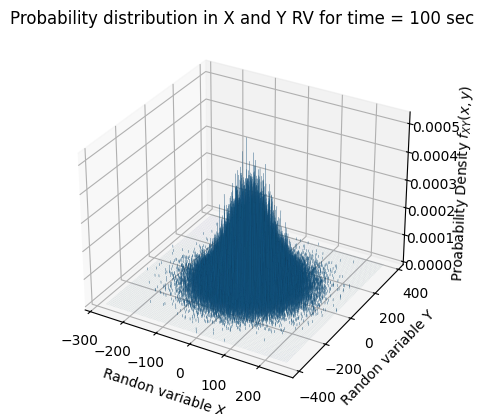

In [79]:
fig_3_1000 = plt.figure()
ax_3_1000 = fig_3_1000.add_subplot(projection='3d')
hist_3_1000, xedges_3_1000, yedges_3_1000 = np.histogram2d(x_data_hist_3_1000, y_data_hist_3_1000, bins=200)

# Construct arrays for the anchor positions of the 16 bars.
xpos_3_1000, ypos_3_1000 = np.meshgrid(xedges_3_1000[:-1] , yedges_3_1000[:-1], indexing="ij")
xpos_3_1000 = xpos_3_1000.ravel()
ypos_3_1000 = ypos_3_1000.ravel()
zpos_3_1000 = 0

# Construct arrays with the dimensions for the 16 bars.
dx_3_1000 = dy_3_1000 = 0.5 * np.ones_like(zpos_3_1000)
dz_3_1000 = hist_3_1000.ravel()/100000

ax_3_1000.bar3d(xpos_3_1000, ypos_3_1000, zpos_3_1000, dx_3_1000, dy_3_1000, dz_3_1000, zsort='average')
ax_3_1000.set_title("Probability distribution in X and Y RV for time = 100 sec")
ax_3_1000.set_xlabel("Randon variable X")
ax_3_1000.set_ylabel("Randon variable Y")
ax_3_1000.set_zlabel(r"Proabability Density $f_{XY}(x,y)$")
plt.show()
ax_3_1000.get_figure().savefig('pdf_3_1000_3d.png', dpi=300, bbox_inches='tight')

## Case 4

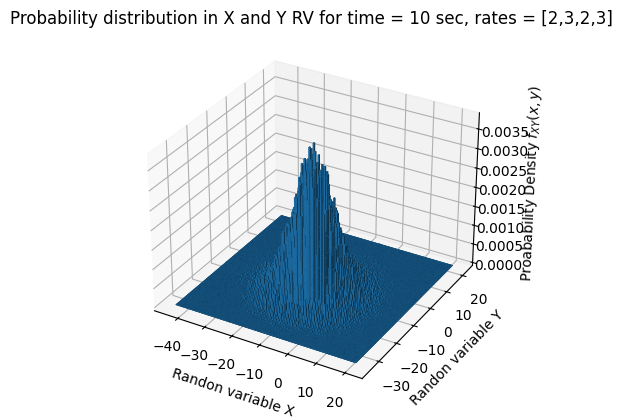

In [80]:
fig_4 = plt.figure()
ax_4 = fig_4.add_subplot(projection='3d')
hist_4, xedges_4, yedges_4 = np.histogram2d(x_data_hist_4, y_data_hist_4, bins=200)

# Construct arrays for the anchor positions of the 16 bars.
xpos_4, ypos_4 = np.meshgrid(xedges_4[:-1] , yedges_4[:-1], indexing="ij")
xpos_4 = xpos_4.ravel()
ypos_4 = ypos_4.ravel()
zpos_4 = 0

# Construct arrays with the dimensions for the 16 bars.
dx_4 = dy_4 = 0.5 * np.ones_like(zpos_4)
dz_4 = hist_4.ravel()/100000

ax_4.bar3d(xpos_4, ypos_4, zpos_4, dx_4, dy_4, dz_4, zsort='average')
ax_4.set_title("Probability distribution in X and Y RV for time = 10 sec, rates = [2,3,2,3]")
ax_4.set_xlabel("Randon variable X")
ax_4.set_ylabel("Randon variable Y")
ax_4.set_zlabel(r"Proabability Density $f_{XY}(x,y)$")
plt.show()
ax_4.get_figure().savefig('pdf_4_10_3d.png', dpi=300, bbox_inches='tight')

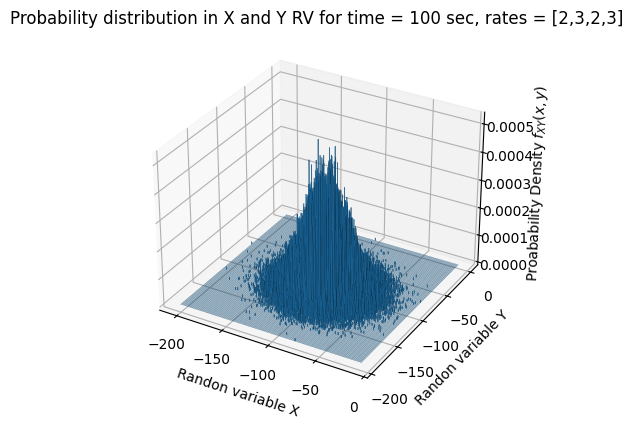

In [81]:
fig_4_100 = plt.figure()
ax_4_100 = fig_4_100.add_subplot(projection='3d')
hist_4_100, xedges_4_100, yedges_4_100 = np.histogram2d(x_data_hist_4_100, y_data_hist_4_100, bins=200)

# Construct arrays for the anchor positions of the 16 bars.
xpos_4_100, ypos_4_100 = np.meshgrid(xedges_4_100[:-1] , yedges_4_100[:-1], indexing="ij")
xpos_4_100 = xpos_4_100.ravel()
ypos_4_100 = ypos_4_100.ravel()
zpos_4_100 = 0

# Construct arrays with the dimensions for the 16 bars.
dx_4_100 = dy_4_100 = 0.5 * np.ones_like(zpos_4_100)
dz_4_100 = hist_4_100.ravel()/100000

ax_4_100.bar3d(xpos_4_100, ypos_4_100, zpos_4_100, dx_4_100, dy_4_100, dz_4_100, zsort='average')
ax_4_100.set_title("Probability distribution in X and Y RV for time = 100 sec, rates = [2,3,2,3]")
ax_4_100.set_xlabel("Randon variable X")
ax_4_100.set_ylabel("Randon variable Y")
ax_4_100.set_zlabel(r"Proabability Density $f_{XY}(x,y)$")
plt.show()
ax_4_100.get_figure().savefig('pdf_4_100_3d.png', dpi=300, bbox_inches='tight')

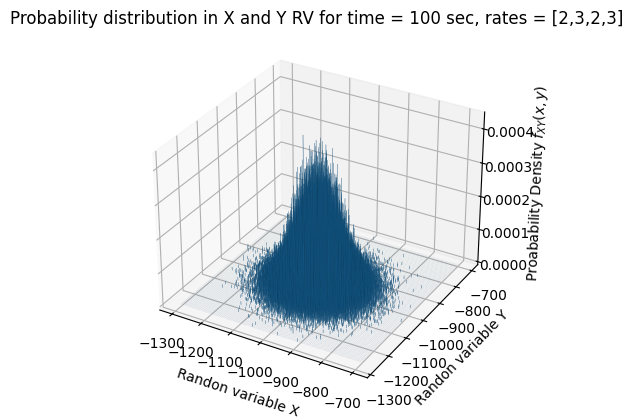

In [82]:
fig_4_1000 = plt.figure()
ax_4_1000 = fig_4_1000.add_subplot(projection='3d')
hist_4_1000, xedges_4_1000, yedges_4_1000 = np.histogram2d(x_data_hist_4_1000, y_data_hist_4_1000, bins=200)

# Construct arrays for the anchor positions of the 16 bars.
xpos_4_1000, ypos_4_1000 = np.meshgrid(xedges_4_1000[:-1] , yedges_4_1000[:-1], indexing="ij")
xpos_4_1000 = xpos_4_1000.ravel()
ypos_4_1000 = ypos_4_1000.ravel()
zpos_4_1000 = 0

# Construct arrays with the dimensions for the 16 bars.
dx_4_1000 = dy_4_1000 = 0.5 * np.ones_like(zpos_3_1000)
dz_4_1000 = hist_4_1000.ravel()/100000

ax_4_1000.bar3d(xpos_4_1000, ypos_4_1000, zpos_4_1000, dx_4_1000, dy_4_1000, dz_4_1000, zsort='average')
ax_4_1000.set_title("Probability distribution in X and Y RV for time = 100 sec, rates = [2,3,2,3]")
ax_4_1000.set_xlabel("Randon variable X")
ax_4_1000.set_ylabel("Randon variable Y")
ax_4_1000.set_zlabel(r"Proabability Density $f_{XY}(x,y)$")
plt.show()
ax_4_1000.get_figure().savefig('pdf_4_1000_3d.png', dpi=300, bbox_inches='tight')